# **Project Name**    - DeepFER: Facial Emotion Recognition Using Deep Learning

# **Project Summary -**

DeepFER: Facial Emotion Recognition Using Deep Learning is a deep learning-based system designed to recognize human emotions from facial expressions in real-time. The project leverages Convolutional Neural Networks (CNNs) and Transfer Learning to classify images into seven emotion categories: Angry, Sad, Happy, Fear, Neutral, Disgust, and Surprise.

With growing interest in emotion-aware systems, this project aims to bridge the gap between human emotions and machine understanding. It uses a diverse and well-annotated dataset of facial images, incorporating both posed and spontaneous expressions. To improve model generalization and robustness, various data augmentation techniques like rotation, flipping, and zooming are applied during preprocessing.

The model architecture is carefully designed and fine-tuned using state-of-the-art deep learning techniques, and optimized for real-time emotion detection. The ultimate goal of DeepFER is to enable practical applications in domains like mental health monitoring, customer service feedback systems, and human-computer interaction, where recognizing human emotions can significantly enhance user experience and responsiveness.

### Import Libraries

In [53]:
# Import libraries

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

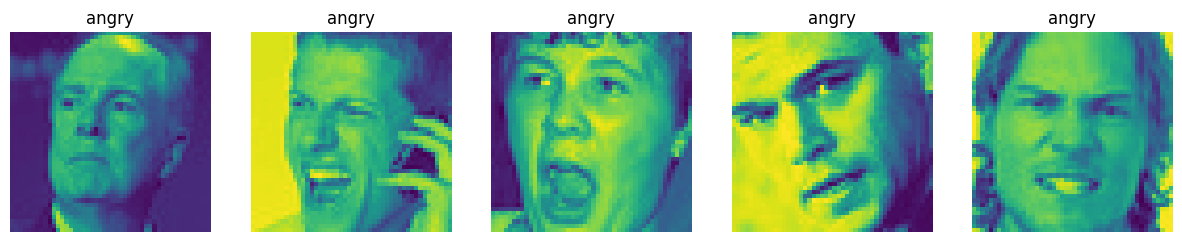

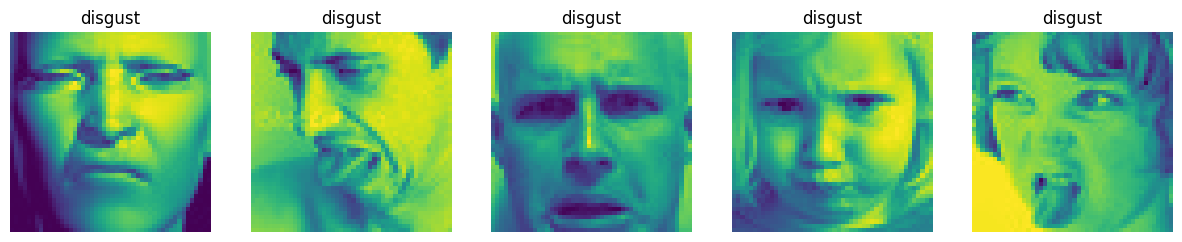

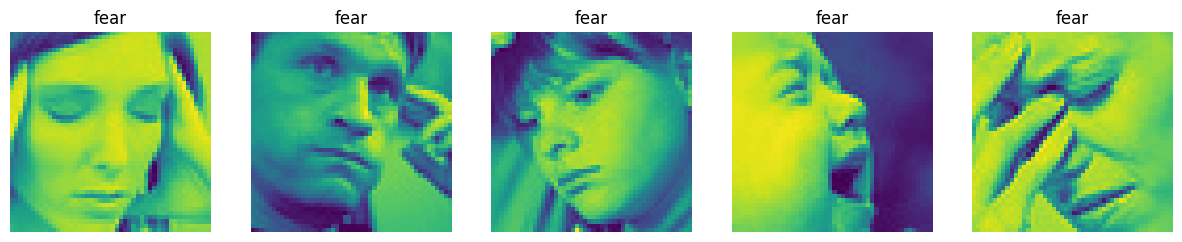

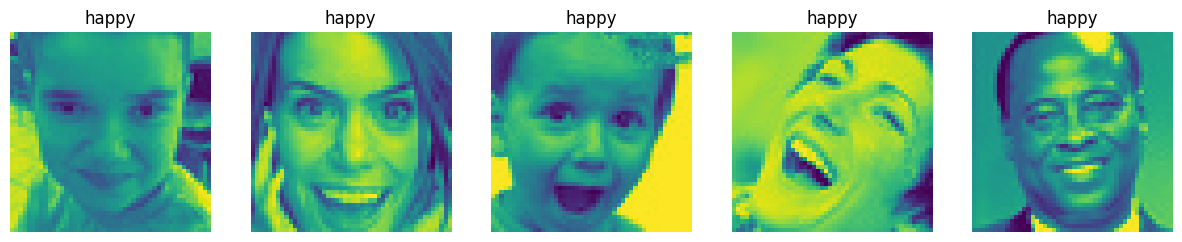

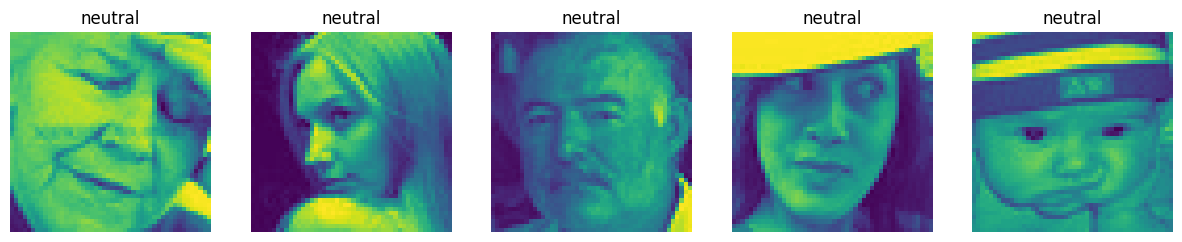

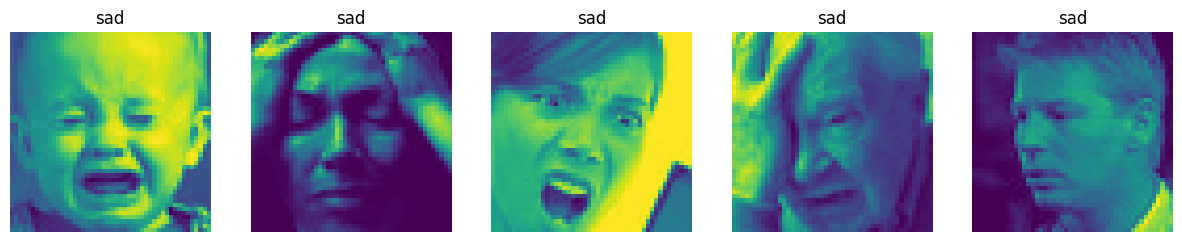

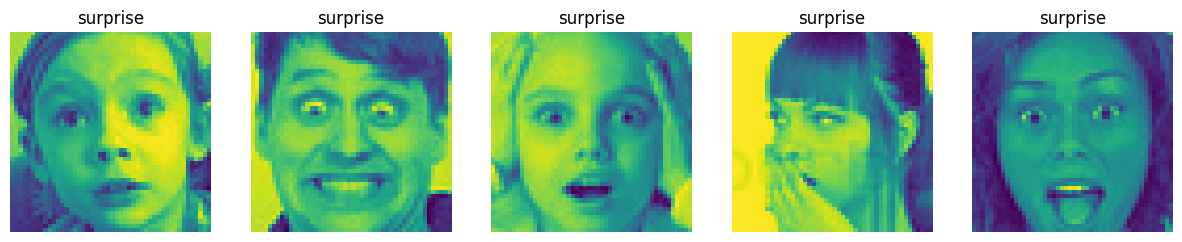

In [54]:
# Visualizing random 5 images of the every facial expression of the train data

train_dir = "original_images/train"
train_dir_classes = os.listdir(train_dir)

for classes in train_dir_classes:
    class_path = os.path.join(train_dir, classes)

    img_name = os.listdir(class_path)
    
    random5 = random.sample(img_name, 5)
    
    plt.figure(figsize = (15,3))
    for index,img in enumerate(random5):
        img_complete_path = os.path.join(class_path, img)
        img = Image.open(img_complete_path)
        
        plt.subplot(1, 5, index+1)
        plt.imshow(img)
        plt.title(classes)
        plt.axis("off")
    plt.show()
    


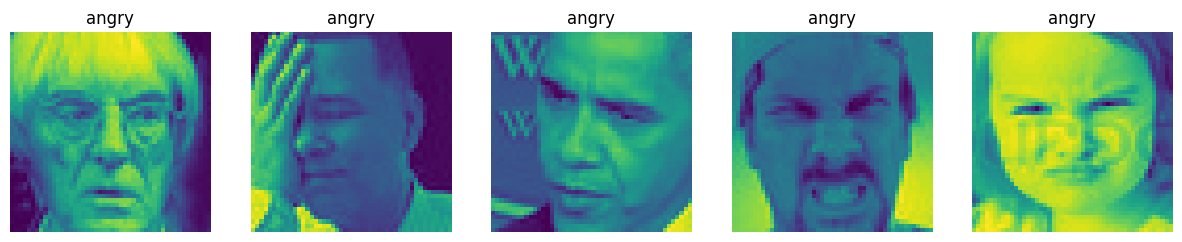

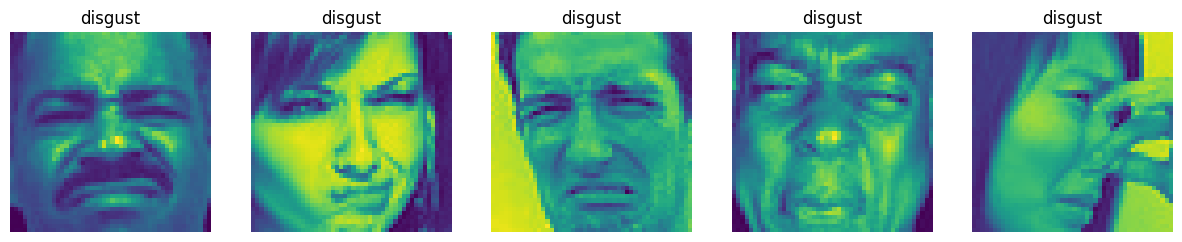

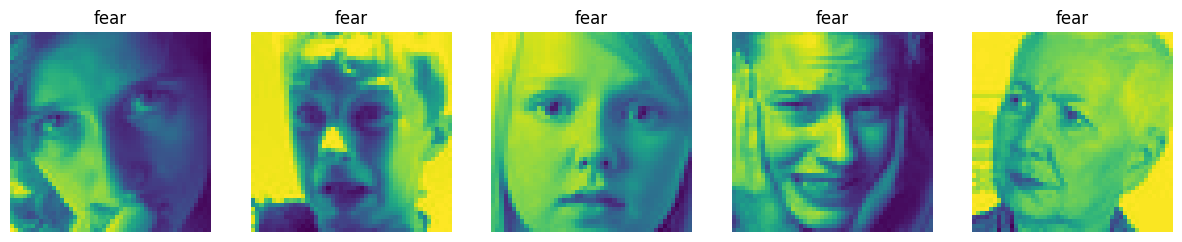

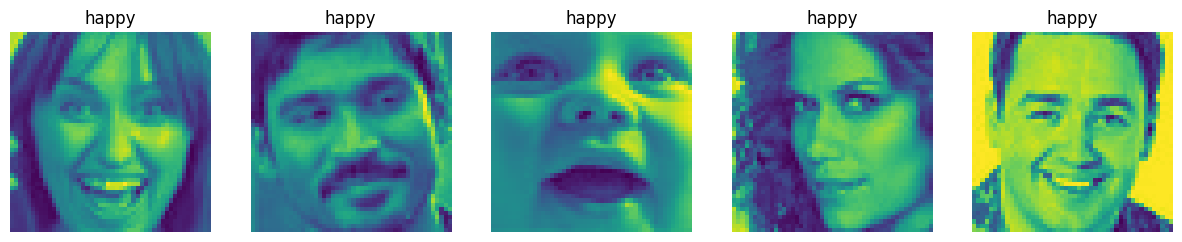

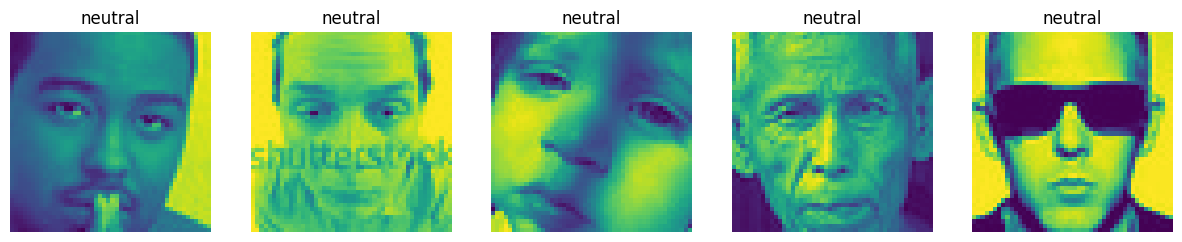

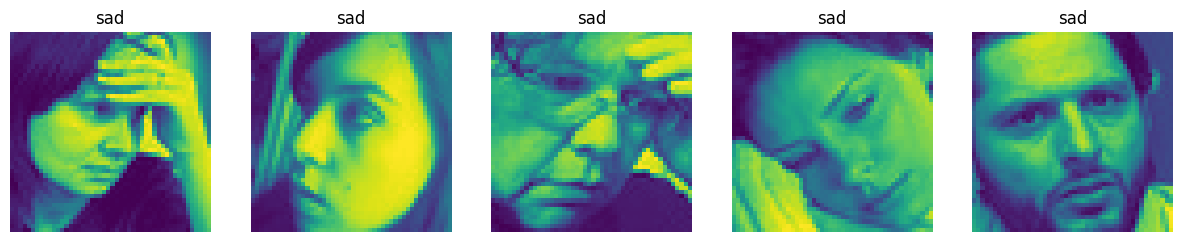

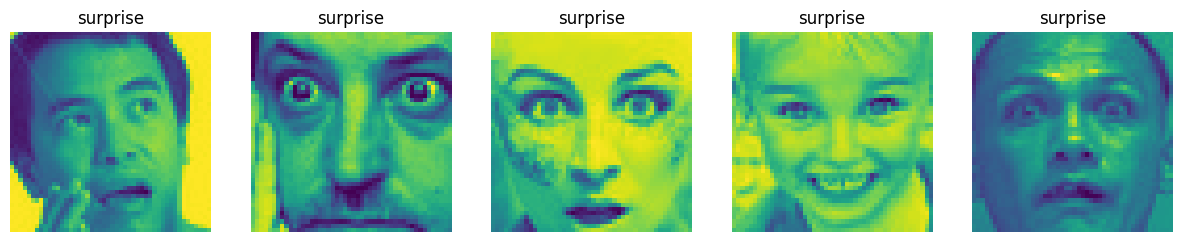

In [55]:
# Visualizing random 5 images of every facial expression of the Test data (Validation data)

test_dir = "original_images/validation"
test_dir_classes = os.listdir(test_dir)

for classes in test_dir_classes:
    class_path = os.path.join(test_dir, classes)

    img_name = os.listdir(class_path)
    
    random5 = random.sample(img_name, 5)
    
    plt.figure(figsize = (15,3))
    for index,img in enumerate(random5):
        img_complete_path = os.path.join(class_path, img)
        img = Image.open(img_complete_path)
        
        plt.subplot(1, 5, index+1)
        plt.imshow(img)
        plt.title(classes)
        plt.axis("off")
    plt.show()

### Images Count

In [56]:
# Number of images in training folder

train_dir = "original_images/train"
train_dir_classes = os.listdir(train_dir)

for classes in train_dir_classes:
    class_path = os.path.join(train_dir, classes)

    img_name = os.listdir(class_path)
    print(f"Number of Images in {classes}:",len(img_name))
    

Number of Images in angry: 3995
Number of Images in disgust: 436
Number of Images in fear: 4097
Number of Images in happy: 7215
Number of Images in neutral: 4965
Number of Images in sad: 4830
Number of Images in surprise: 3171


In [57]:
# Number of Images in testing(Validation) folder

test_dir = "original_images/validation"
test_dir_classes = os.listdir(test_dir)

for classes in test_dir_classes:
    class_path = os.path.join(test_dir, classes)

    img_name = os.listdir(class_path)
    print(f"Number of Images in {classes}:",len(img_name))
    

Number of Images in angry: 958
Number of Images in disgust: 111
Number of Images in fear: 1024
Number of Images in happy: 1774
Number of Images in neutral: 1233
Number of Images in sad: 1247
Number of Images in surprise: 831


### Duplicate Images

In [58]:
# Identifying duplicate images

import hashlib
from pathlib import Path

def hasher_images(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        img = f.read()
    hasher.update(img)
    return hasher.hexdigest()

duplicates = []
images = {}

for root, dirs, files in os.walk("original_images/train"):
    for file in files:
        img_path = os.path.join(root ,file).replace("\\","/")
        
        hash_value = hasher_images(img_path)
        
        if hash_value in images:
            duplicates.append((hash_value, img_path))
        else:
            images[hash_value] = img_path

print(len(duplicates))

1236


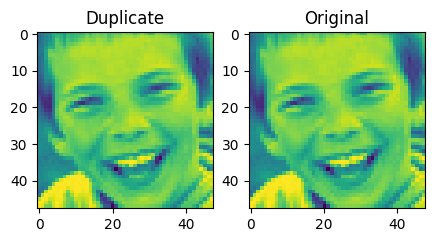

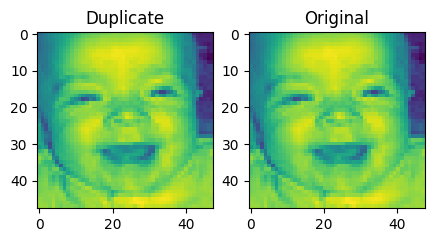

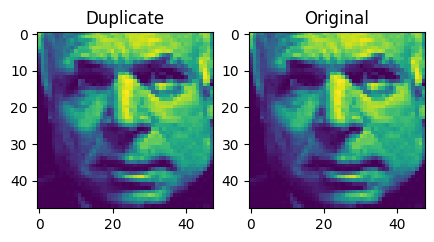

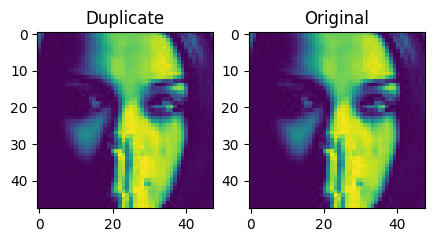

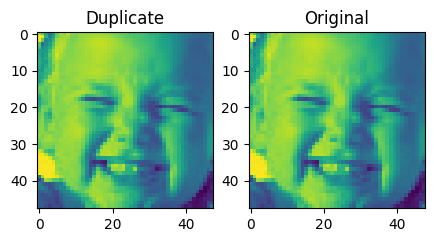

In [59]:
# Randomly sample up to 5 pairs
random5 = random.sample(duplicates, 5)

for hash_value, img_path in random5:
    duplicates_img_path = img_path
    original_img_path = images[hash_value]
    
    plt.figure(figsize = (5,3))
    plt.subplot(1,2,1)
    duplicates_img = Image.open(duplicates_img_path)
    plt.imshow(duplicates_img)
    plt.title("Duplicate")
    
    plt.subplot(1,2,2)
    original_img = Image.open(original_img_path)
    plt.imshow(original_img)
    plt.title("Original")
    
    plt.show()

In [60]:
# Checking which duplicate image belongs to which classes

import hashlib

def hasher_images(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        img = f.read()
    hasher.update(img)
    return hasher.hexdigest()

duplicate = []
images = {}

for root, dirs, files in os.walk("original_images/train"):
    for file in files:
        img_path = os.path.join(root, file).replace("\\","/")
        hash_value = hasher_images(img_path)
        
        if hash_value in images:
            duplicate.append((hash_value, img_path))
        else:
            images[hash_value] = img_path

In [61]:

duplicates_different_classes = 0

for hash_value , img_path in duplicate:
    duplicates_img_path = img_path
    original_img_path = images[hash_value]
    
    duplicate_img_class = os.path.split(duplicates_img_path)[0].split("/")[-1]
    original_img_path = os.path.split(original_img_path)[0].split("/")[-1]
    
    if duplicate_img_class != original_img_path:
        duplicates_different_classes +=1 
        print("Original_emotion :", original_img_path)
        print("Duplicate_emotion:", duplicate_img_class)
        
print(duplicates_different_classes)
print(duplicate_img_class)
        
    

Original_emotion : angry
Duplicate_emotion: fear
Original_emotion : angry
Duplicate_emotion: fear
Original_emotion : disgust
Duplicate_emotion: fear
Original_emotion : angry
Duplicate_emotion: fear
Original_emotion : angry
Duplicate_emotion: fear
Original_emotion : angry
Duplicate_emotion: happy
Original_emotion : fear
Duplicate_emotion: neutral
Original_emotion : fear
Duplicate_emotion: neutral
Original_emotion : fear
Duplicate_emotion: neutral
Original_emotion : fear
Duplicate_emotion: neutral
Original_emotion : angry
Duplicate_emotion: neutral
Original_emotion : angry
Duplicate_emotion: neutral
Original_emotion : angry
Duplicate_emotion: neutral
Original_emotion : fear
Duplicate_emotion: sad
Original_emotion : angry
Duplicate_emotion: sad
Original_emotion : fear
Duplicate_emotion: sad
Original_emotion : angry
Duplicate_emotion: sad
Original_emotion : angry
Duplicate_emotion: sad
Original_emotion : angry
Duplicate_emotion: sad
Original_emotion : angry
Duplicate_emotion: sad
Original_

### Corrupt Images

In [62]:
# Missing Values/Null Values Count

from PIL import Image

def check_missing_or_currupt_images(directory):
    corrupt_images = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()
            except:
                corrupt_images.append(path)
            
    print(f"Corrupt or Unreadabe Images: {len(corrupt_images)}")
    return corrupt_images

# Check both train or validation(test) sets
corrupt_train = check_missing_or_currupt_images(train_dir)
corrupt_val = check_missing_or_currupt_images(test_dir)

Corrupt or Unreadabe Images: 0
Corrupt or Unreadabe Images: 0


# Dataset Summary and Analysis

## Dataset Structure
The dataset is organized into two main folders:
- **Train**
- **Validation**

Inside each folder, there are **7 class folders**, representing the emotion categories:
- `happy`
- `surprise`
- `neutral`
- `fear`
- `disgust`
- `sad`
- `angry`

---

## Image Distribution

| Folder        | Class     | Image Count |
|----------------|-----------|--------------|
| **Train**      | Happy     | 7164         |
|                | Surprise  | 3205         |
|                | Neutral   | 4982         |
|                | Fear      | 4103         |
|                | Disgust   | 436          |
|                | Sad       | 4938         |
|                | Angry     | 3993         |
| **Total Train**|           | **28821**    |
|----------------|-----------|--------------|
| **Validation** | Happy     | 1825         |
|                | Surprise  | 797          |
|                | Neutral   | 1216         |
|                | Fear      | 1018         |
|                | Disgust   | 111          |
|                | Sad       | 1139         |
|                | Angry     | 960          |
| **Total Val**  |           | **7066**     |

---

## Duplicate Image Analysis
- **Total Duplicate Files Found:** **1853**
- **Duplicates Found Across Different Classes:** **80**

> Some images are shared between different emotion categories, which can cause label confusion if not handled properly.

---

## Corrupted Files Check
- **Corrupt or Unreadable Images:** **0**

> The dataset has no corrupted or unreadable images.

---

## Key Observations
- The dataset is **imbalanced**, with the **'Disgust'** class having very few images compared to other classes.
- A significant number of **duplicate images (1853)** were found.
- **80 cross-class duplicates** were detected, meaning the same image is labeled under different emotion categories.
- No corrupted images were found, so the dataset is clean in that regard.

---

# 3. Data Wrangling

##### Removing the duplicates from the preprocessed folder which is the copy of the original images folder. It is done to ensure that the initial set of images remain untouched.

In [66]:
import os
import hashlib

def md5_hasher(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        file = f.read()
        hasher.update(file)
    return hasher.hexdigest()

# Function to finf duplicate images
def find_duplicates(folder_path):
    hashes = {}
    duplicates = [] 
    
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                file_hash = md5_hasher(file_path)
                
                if file_hash in hashes:
                    duplicates.append((file_path, hashes[file_hash]))
                else:
                    hashes[file_hash] = file_path
            
            except Exception as e:
                print(f"Error : {e}")
                
    return duplicates

dups = find_duplicates('preprocessed_images')
print(f"Total duplicate file found: {len(dups)}")
                

Total duplicate file found: 0


In [64]:
# Removing duplicates 
for dup in dups:
    duplicate_file = dup[0]

    if os.path.exists(duplicate_file):
        try:
            os.remove(duplicate_file)
            
        except Exception as e:
            print("Error while remoiving", e)

print("Duplicates Images are removed")

Duplicates Images are removed


Total duplicate file found: 0
